In [20]:
import pandas as pd

In [21]:
raw_data = pd.read_csv("C:/Users/Admin/Desktop/PaySim_Fraud_Detection/PaySim_Data/paysim dataset.csv")
df  = raw_data.copy()

In [22]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [24]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [26]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [27]:
# 1. Class balance — how rare is fraud?
print(df['isFraud'].value_counts())
print(df['isFraud'].mean())          # fraud rate as a proportion

isFraud
0    6354407
1       8213
Name: count, dtype: int64
0.001290820448180152


In [28]:
# 2. Transaction types present
print(df['type'].value_counts())

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


In [29]:
# 3. THE key insight — fraud count and fraud rate within each type
print(df.groupby('type')['isFraud'].sum())    # how many frauds per type
print(df.groupby('type')['isFraud'].mean())   # fraud rate per type

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64
type
CASH_IN     0.000000
CASH_OUT    0.001840
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.007688
Name: isFraud, dtype: float64


In [30]:
# 4. How many transactions did PaySim's built-in rule flag?
print(df['isFlaggedFraud'].sum())

16


In [31]:
# 5. Missing values
print(df.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [32]:
# 6. Column data types (needed to design the MySQL table)
print(df.dtypes)

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


In [35]:
# Phase 2.1 — filter to the two fraud-bearing types. Run this:

In [36]:
# Phase 2.1 — keep only the transaction types where fraud actually occurs
df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

# verify the filter
print(df.shape)
print(df['isFraud'].value_counts())
print(df['type'].value_counts())

(2770409, 11)
isFraud
0    2762196
1       8213
Name: count, dtype: int64
type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64


In [40]:
# Phase 2.2 — balance-consistency features (from EDA 1.3 and 1.4)

# Origin account should DROP by the amount: expected new balance = old - amount
df['errorBalanceOrig'] = (df['oldbalanceOrg'] - df['amount']) - df['newbalanceOrig']

# Destination account should RISE by the amount: expected new balance = old + amount
df['errorBalanceDest'] = (df['oldbalanceDest'] + df['amount']) - df['newbalanceDest']

# compare the new features for fraud vs legit
print(df.groupby('isFraud')[['errorBalanceOrig', 'errorBalanceDest']].mean())

         errorBalanceOrig  errorBalanceDest
isFraud                                    
0          -286803.509954     -30910.325352
1           -10692.325265     732509.301069


In [43]:
# Phase 2.3 — encode type and assemble features (X) and target (y)

# only two types remain → encode as a single 0/1 column
df['type_code'] = df['type'].map({'TRANSFER': 1, 'CASH_OUT': 0})

# the columns the model will actually learn from
features = [
    'amount',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'errorBalanceOrig', 'errorBalanceDest',
    'type_code'
]

X = df[features]
y = df['isFraud']

print(X.shape)
print(y.shape)
print(y.value_counts())
print(X.head())

(2770409, 8)
(2770409,)
isFraud
0    2762196
1       8213
Name: count, dtype: int64
       amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  newbalanceDest  \
2      181.00          181.0             0.0             0.0            0.00   
3      181.00          181.0             0.0         21182.0            0.00   
15  229133.94        15325.0             0.0          5083.0        51513.44   
19  215310.30          705.0             0.0         22425.0            0.00   
24  311685.89        10835.0             0.0          6267.0      2719172.89   

    errorBalanceOrig  errorBalanceDest  type_code  
2               0.00             181.0          1  
3               0.00           21363.0          0  
15        -213808.94          182703.5          0  
19        -214605.30          237735.3          1  
24        -300850.89        -2401220.0          1  


In [44]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceOrig,errorBalanceDest,type_code
2,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,0.00,181.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,0.00,21363.0,0
15,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,-213808.94,182703.5,0
19,1,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,-214605.30,237735.3,1
24,1,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,-300850.89,-2401220.0,1


In [45]:
# Phase 2.4 — split into train and test BEFORE any scaling or model fitting
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,     # hold out 30% to test on unseen data
    stratify=y,         # keep the same fraud rate in both sets
    random_state=42     # same split every run (reproducible)
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())
print(y_train.mean(), y_test.mean())

(1939286, 8) (831123, 8)
isFraud
0    1933537
1       5749
Name: count, dtype: int64
isFraud
0    828659
1      2464
Name: count, dtype: int64
0.0029644931175700747 0.002964663473396838


In [46]:
# Phase 2.5 — Logistic Regression baseline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

# 1. Scale features — fit on TRAIN only, then apply to both (leakage-safe)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 2. Train logistic regression; class_weight handles the rare fraud class
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

# 3. Predict fraud probability for each test transaction
y_pred_proba = logreg.predict_proba(X_test_scaled)[:, 1]

# 4. Evaluate with imbalance-appropriate metrics
print("AUPRC:", average_precision_score(y_test, y_pred_proba))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

AUPRC: 0.5589776916501248
ROC-AUC: 0.976033192330472


In [47]:
# Phase 2.6 — XGBoost model
from xgboost import XGBClassifier

# scale_pos_weight = how many legit per fraud, computed from TRAIN only
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

# NOTE: XGBoost uses the RAW (unscaled) features — trees split on thresholds
xgb.fit(X_train, y_train)

y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("AUPRC:", average_precision_score(y_test, y_pred_proba_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb))

scale_pos_weight: 336.3257957905723
AUPRC: 0.9944130413335546
ROC-AUC: 0.9981851129550681


In [48]:
# Phase 2.7 — benchmark the two models side by side
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'AUPRC': [
        average_precision_score(y_test, y_pred_proba),       # logistic
        average_precision_score(y_test, y_pred_proba_xgb)    # xgboost
    ],
    'ROC_AUC': [
        roc_auc_score(y_test, y_pred_proba),
        roc_auc_score(y_test, y_pred_proba_xgb)
    ]
})

print(results)

                 Model     AUPRC   ROC_AUC
0  Logistic Regression  0.558978  0.976033
1              XGBoost  0.994413  0.998185


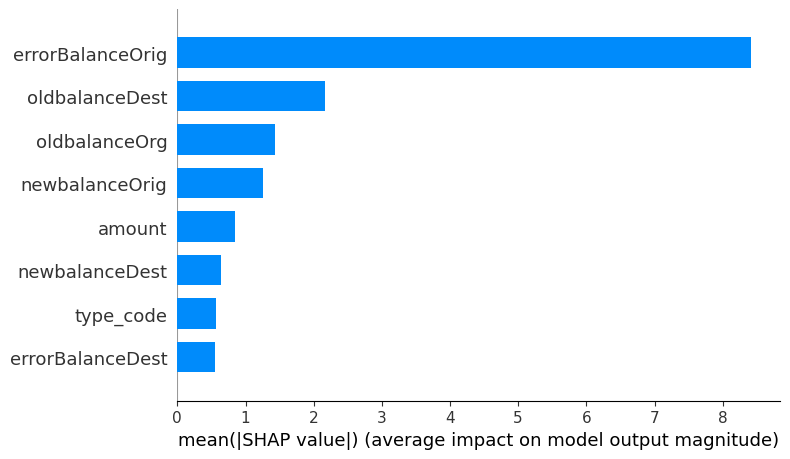

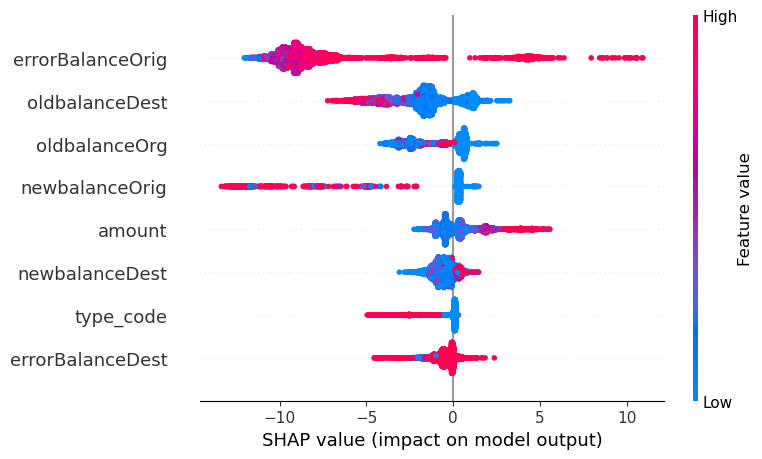

In [51]:
# Phase 2.8 — SHAP: which features drive the XGBoost model?
import shap

# SHAP on all 831K rows is slow; a random sample gives the same picture
X_sample = X_test.sample(n=10000, random_state=42)

# TreeExplainer is the fast, exact SHAP method for tree models
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_sample)

# clean importance ranking (easiest to read)
shap.summary_plot(shap_values, X_sample, plot_type="bar")

# directional view (which feature values push a prediction toward fraud)
shap.summary_plot(shap_values, X_sample)

In [50]:
# Phase 2.9 — confusion matrix and per-class scores at the default 0.5 threshold
from sklearn.metrics import confusion_matrix, classification_report

y_pred_xgb = (y_pred_proba_xgb >= 0.5).astype(int)   # probabilities -> 0/1

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, digits=4))

[[828458    201]
 [    11   2453]]
              precision    recall  f1-score   support

           0     1.0000    0.9998    0.9999    828659
           1     0.9243    0.9955    0.9586      2464

    accuracy                         0.9997    831123
   macro avg     0.9621    0.9976    0.9792    831123
weighted avg     0.9998    0.9997    0.9997    831123

